Importing required libraries 

In [1]:
from torch import nn 
import torch
from torchvision import transforms

Accessing GPU

In [2]:
torch.cuda.is_available() 

device = "cuda" if torch.cuda.is_available() else "cpu"

Creating train test and valid datasets

In [3]:
#importing dataset for transformation 
from utility import dentalDataset

#transformation operation
dataTransform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

#creating train,test and validation datasets
train_data = dentalDataset(root_dir = "dental_dataset/train", transform = dataTransform)
validation_data = dentalDataset(root_dir = "dental_dataset/valid", transform = dataTransform)
test_data = dentalDataset(root_dir = "dental_dataset/test", transform = dataTransform)


Viewing classes

In [4]:

import pandas as pd
class_names = train_data.class_names
print(f"The classes present in the dataset are: {class_names}\n")

class_list = pd.Series(class_names).value_counts() 
print("The number of each class in the data are:")
print(class_list)

The classes present in the dataset are: ['caries', 'cavity', 'gingivitis', 'gum_swelling', 'healthy', 'plaque']

The number of each class in the data are:
caries          1
cavity          1
gingivitis      1
gum_swelling    1
healthy         1
plaque          1
Name: count, dtype: int64


Creating dataloaders

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32 

train_dataloader = DataLoader(dataset = train_data,batch_size = BATCH_SIZE,shuffle = True)
test_dataloader = DataLoader(dataset = test_data,batch_size = BATCH_SIZE, shuffle = False) 
validation_dataloader = DataLoader(dataset = validation_data, batch_size = BATCH_SIZE, shuffle = True)

Information of dataloaders

In [6]:
print(f"Dataloaders: {train_dataloader, test_dataloader, validation_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of validation dataloader: {len(validation_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")


train_features_batch, train_labels_batch = next(iter(train_dataloader))
#unpacking content of train dataloader 
print(train_features_batch.shape)
print(train_labels_batch.shape)


Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000259699C30E0>, <torch.utils.data.dataloader.DataLoader object at 0x0000025969A91D10>, <torch.utils.data.dataloader.DataLoader object at 0x0000025969A920D0>)
Length of train dataloader: 153 batches of 32
Length of validation dataloader: 22 batches of 32
Length of test dataloader: 20 batches of 32
torch.Size([32, 3, 224, 224])
torch.Size([32])


Viewing sample from dataset

Tensor shape: torch.Size([3, 224, 224])
Label index: 1
Class name: cavity
6


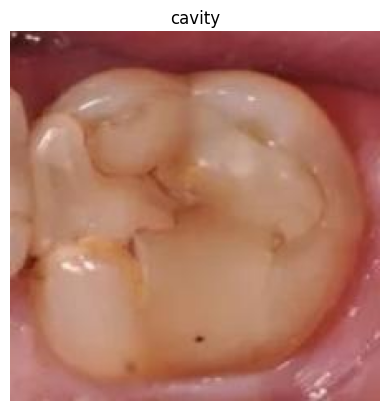

In [7]:
#viewing a sample
import torch
import matplotlib.pyplot as plt

#Getting a random sample from the batch
random_idx = torch.randint(
    low=0,
    high=train_features_batch.size(0),
    size=(1,)
).item()

#Extracting image and label
img = train_features_batch[random_idx]      
label = train_labels_batch[random_idx]      


#Converting to H,W,C for matplotlib
img_vis = img.permute(1, 2, 0)

plt.imshow(img_vis)
plt.title(class_names[int(label)])
plt.axis("off")

# Debug / verification prints
print(f"Tensor shape: {img.shape}")      
print(f"Label index: {int(label)}")
print(f"Class name: {class_names[int(label)]}")
print(len(class_names))


Creating model

In [8]:
class CNNSENetModel(nn.Module):
    """CNN with SE net"""
    def __init__(self):
        super().__init__()

        #Creating CNN
        self.block1 = nn.Sequential(
            nn.Conv2d(3,100,kernel_size=3, stride = 1, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size =3, stride =1)
                      
        )
        
        #SE net block
        self.SENet = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            #adding reduction factor of '16'
            nn.Linear(in_features = 100, out_features = 100//16),
            nn.ReLU(),
            #100 out features because it is for each 100 channels
            nn.Linear(in_features = 100//16, out_features =100),
            nn.Sigmoid()

        )

        #classifiying 
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(in_features = 100, out_features =6)
        )

    #performing forward pass so the model is able to update its weights and biases
    def forward(self,x):
        x = self.block1(x)
        #getting features from convolution layer
        features = x
        #generating weights 
        attention = self.SENet(x)
        #reshaping, adding new channels to prevent shape mismatch
        attention = attention[:,:,None,None]
        #scale operation
        x = features * attention 
        x = self.classifier(x) 
        return x

Creating instance of model 

In [9]:
CNNSENet = CNNSENetModel().to(device)

Timer for our model

In [10]:
from timeit import default_timer 
def print_train_time(start:float, end:float, device:device):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

Setting up functions for accuracy, loss, optimization and evaluation metrics calculation

In [11]:
from utility import accuracy_fn, precision_recall_f1
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(params = CNNSENet.parameters(), lr = 1e-4)


Training and Testing our model

In [12]:
from utility import train_step, test_step
from tqdm import tqdm #progress bar
train_time_start = default_timer() 

epochs = 6 
for epoch in tqdm(range(epochs)):
    print(f"Epoch:{epoch}")
    train_step(model = CNNSENet,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer, 
               accuracy_fn = accuracy_fn, 
               device = device)
    test_step(model = CNNSENet,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
              device = device)
    
train_time_end = default_timer() 
total_train_time = print_train_time(start=train_time_start, end = train_time_end, device = device)



  0%|          | 0/6 [00:00<?, ?it/s]

Epoch:0
Train loss: 1.74604 | Train accuracy: 35.00% | Precision:0.1710 | Recall :0.1005 | f1-score: 0.1094


 17%|█▋        | 1/6 [00:21<01:45, 21.05s/it]

Test loss: 1.73785 | Test accuracy: 26.36% | Precision:0.1667 | Recall :0.0428 | f1-score: 0.0681
Epoch:1
Train loss: 1.63981 | Train accuracy: 38.83% | Precision:0.1667 | Recall :0.0649 | f1-score: 0.0934


 33%|███▎      | 2/6 [00:36<01:11, 17.76s/it]

...

Test loss: 1.72274 | Test accuracy: 26.36% | Precision:0.1667 | Recall :0.0428 | f1-score: 0.0681
Epoch:4
Train loss: 1.58268 | Train accuracy: 38.95% | Precision:0.1667 | Recall :0.0649 | f1-score: 0.0934


 83%|████████▎ | 5/6 [01:30<00:18, 18.05s/it]

Test loss: 1.72652 | Test accuracy: 26.36% | Precision:0.1667 | Recall :0.0428 | f1-score: 0.0681
Epoch:5
Train loss: 1.58294 | Train accuracy: 38.86% | Precision:0.1667 | Recall :0.0649 | f1-score: 0.0934


100%|██████████| 6/6 [01:49<00:00, 18.28s/it]

Test loss: 1.72410 | Test accuracy: 26.36% | Precision:0.1667 | Recall :0.0428 | f1-score: 0.0681
Train time on cuda: 109.701 seconds
